In [2]:
## Test GPU
import torch

def get_device():
    """Get the appropriate device for model inference."""
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = get_device()

print(f"Using device: {DEVICE}")

Using device: cuda


## create the dataset in the db

```
python launch_remote.py --root /share/home/e2406743/dataset --NCcsv /share/home/e2406743/dataset/dataset/NC/dugong_environmental_variables_NC.csv --WPcsv /share/home/e2406743/dataset/dataset/WP/dugong_environmental_variables_WP.xlsx --launch false --name_dataset dugong --path_database /share/home/e2406743/fiftyone/mongodb --port_database 44123
```
## create manually the mongodb service

```bash
# 1. Kill any old "ghost" processes
pkill -u $(whoami) -f mongod

# 2. Start the database manually
 # Use your /tmp path for speed, or /share/projects/... for persistence
mongod --dbpath /share/home/e2406743/fiftyone/mongodb --port 44123 --fork --logpath /share/home/e2406743/fiftyone/mongodb/mongo.log
 # OR IF IN TEMP FOLDER 
mongod --dbpath /tmp/e2406743/mongodb --port 44123 --logpath /tmp/e2406743/mongodb/mongo.log --fork
```

/share/home/e2406734/fiftyone/mongodb 

In [3]:
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 
# STICK to localhost:44123 

You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [4]:
fo.list_datasets()

['FLPLAN', 'dugong', 'flplan200', 'flplanpatches']

In [5]:
from dotenv import load_dotenv
load_dotenv()

import fiftyone as fo
import fiftyone.utils.torch as fout
from huggingface_hub import login

if "HUGGING_FACE_API" in os.environ:
    login(token=os.environ["HUGGING_FACE_API"])

In [18]:
client = fo.core.odm.database.get_db_client()
print(client)  # Should show localhost:44123

MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone')


In [6]:
## if need to create a new dataset
## python launch_remote.py --root /share/home/e2406743/dataset --NCcsv /share/home/e2406743/dataset/dataset/NC/dugong_environmental_variables_NC.csv --WPcsv /share/home/e2406743/dataset/dataset/WP/dugong_environmental_variables_WP.xlsx --launch false --name_dataset dugong --path_database /tmp/e2406734/mongodb --port_database 44123

In [5]:
print(fo.config)

{
    "allow_legacy_orchestrators": false,
    "batcher_static_size": 100,
    "batcher_target_latency": 0.2,
    "batcher_target_size_bytes": 1048576,
    "database_admin": true,
    "database_compressor": null,
    "database_dir": "/share/home/e2406743/.fiftyone/var/lib/mongo",
    "database_name": "fiftyone",
    "database_uri": "mongodb://localhost:44123",
    "database_validation": true,
    "dataset_zoo_dir": "/share/home/e2406743/fiftyone",
    "dataset_zoo_manifest_paths": null,
    "default_app_address": "localhost",
    "default_app_port": 5151,
    "default_batch_size": null,
    "default_batcher": "latency",
    "default_dataset_dir": "/share/home/e2406743/fiftyone",
    "default_image_ext": ".jpg",
    "default_ml_backend": "torch",
    "default_parallelization_method": null,
    "default_process_pool_workers": null,
    "default_sequence_idx": "%06d",
    "default_thread_pool_workers": null,
    "default_video_ext": ".mp4",
    "delegated_operation_monitor_interval": 60,


In [6]:
import fiftyone.zoo as foz
import fiftyone.brain as fob
from fiftyone import ViewField as F
import fiftyone.operators as foo
from fiftyone.utils.huggingface import load_from_hub
import cv2
import numpy as np
import fiftyone.brain as fob
import fiftyone.utils.transformers as fout

In [7]:
    print(fo.core.odm.database.get_db_conn())
    print(fo.core.odm.database.get_db_client())

Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')
MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone')


In [3]:
dataset = fo.load_dataset("dugong")

## load the views
nc_view = dataset.load_saved_view("nc")
wp_view = dataset.load_saved_view("wp")

In [4]:
next(iter(dataset))

<Sample: {
    'id': '69add898cfd942e1c6b5d3ad',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_92.jpeg',
    'tags': [],
    'metadata': <ImageMetadata: {
        'size_bytes': 712381,
        'mime_type': 'image/jpeg',
        'width': 2704,
        'height': 1520,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 3, 8, 20, 14, 16, 713000),
    'last_modified_at': datetime.datetime(2026, 4, 15, 9, 35, 24, 951000),
    'region': 'NC',
    'subregion': 'NC',
    'mission_name': 'Flight_226',
    'sea_state': 0,
    'turbidity_global': 1,
    'turbidity_local': 'no',
    'sun_glitter': '0-0',
    'cloud_reflection': '0-0',
    'habitat_type': 'coral',
    'background_complexity': 'high',
    'coral': 'P',
    'sand': 'A',
    'dense_seagrass': 'A',
    'open_sea': 'P',
    'sparse_seagrass': 'A',
    'ground_truth': <Detections: {
        'detections': [
            <Detection: {
   

In [11]:
## Session launch

In [12]:
# On a cluster: auto=False prevents it trying to open a browser
# Use port forwarding: ssh -L 5151:localhost:5151 user@cluster
session = fo.launch_app(dataset,
                        port=5151,
                        auto=False)
print(session.url)  

Session launched. Run `session.show()` to open the App in a cell output.
http://localhost:5151/


## Model & Processor

In [21]:
from transformers import AutoImageProcessor, AutoModel
import fiftyone.utils.transformers as fout

processor = AutoImageProcessor.from_pretrained("facebook/dinov3-vitl16-pretrain-lvd1689m")
base_model = AutoModel.from_pretrained("facebook/dinov3-vitl16-pretrain-lvd1689m")

# Convert using the transformers utility
# defaults to feature extraction
model = fout.convert_transformers_model(base_model, image_processor=processor)

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

In [11]:
processor

DINOv3ViTImageProcessorFast {
  "data_format": "channels_first",
  "default_to_square": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "DINOv3ViTImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

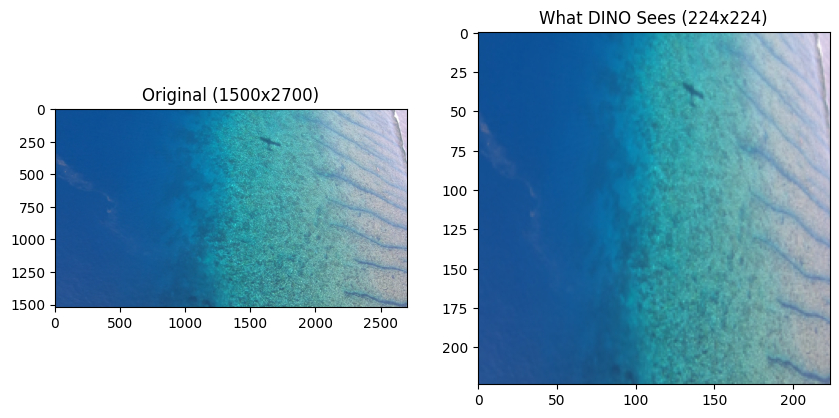

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Grab a sample (e.g., one with a clear Dugong)
sample = dataset.first()
img = Image.open(sample.filepath)

# 2. Run the processor manually (as FiftyOne does internally)
inputs = processor(img, return_tensors="pt")
# Extract pixels, move to CPU, and convert to (H, W, C) for plotting
v_img = inputs["pixel_values"].squeeze(0).permute(1, 2, 0).numpy()

# 3. "Un-normalize" so the colors look normal
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
v_img = (v_img * std) + mean
v_img = np.clip(v_img, 0, 1)

# 4. Plot Comparison
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original (1500x2700)")
plt.imshow(img)
plt.subplot(1, 2, 2)
plt.title("What DINO Sees (224x224)")
plt.imshow(v_img)
plt.show()

In [13]:
print(model)

## Patch Embeddings

In [48]:
import fiftyone.core.models as fom

class DinoV3PatchModel(fom.Model):

    def __init__(self, model, processor, input_size, device=None):
        self.model = model
        self.processor = processor
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.model.eval()
        # Override processor resolution
        self.processor.size = {"height": input_size, "width": input_size}

    @property
    def media_type(self):
        return "image"

    @property
    def has_logits(self):
        return False

    @property
    def has_embeddings(self):
        return True

    @property
    def ragged_batches(self):
        return False

    @property
    def transforms(self):
        return None  # Let embed() handle everything

    def _preprocess(self, img):
        from PIL import Image
        import numpy as np

        if isinstance(img, torch.Tensor):
            img = img.cpu().numpy()
        if isinstance(img, np.ndarray):
            # Fix ambiguous channel dim: if shape is (3, H, 3) or similar,
            # transpose to HWC before converting
            if img.ndim == 3 and img.shape[0] == 3 and img.shape[2] != 3:
                img = img.transpose(1, 2, 0)   # CHW → HWC
            if img.dtype != np.uint8:
                img = (img * 255).clip(0, 255).astype(np.uint8)
            img = Image.fromarray(img)
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)

        # Ensure minimum size — avoids degenerate crops
        w, h = img.size
        if w < 16 or h < 16:
            img = img.resize((max(w, 16), max(h, 16)), Image.LANCZOS)

        return img.convert("RGB")

    def embed(self, img):
        pil = self._preprocess(img)
        inputs = self.processor(images=pil, return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(self.device)  # (1, 3, H, W)
        with torch.inference_mode():
            outputs = self.model(pixel_values=pixel_values)
        return outputs.pooler_output.squeeze(0).cpu().numpy()

    def embed_all(self, imgs):
        from PIL import Image
        pil_imgs = [self._preprocess(img) for img in imgs]
        inputs = self.processor(images=pil_imgs, return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(self.device)  # (B, 3, H, W)
        with torch.inference_mode():
            outputs = self.model(pixel_values=pixel_values)
        return outputs.pooler_output.cpu().numpy()




In [16]:
processor

DINOv3ViTImageProcessorFast {
  "data_format": "channels_first",
  "default_to_square": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "DINOv3ViTImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 448,
    "width": 448
  }
}

In [40]:
# resize the object to 224x224
processor.size = {"height": 224, "width": 224}

model = DinoV3PatchModel(base_model, 
                         processor,
                         input_size = 224
                         )
# Run
patch_embeddings = dataset.compute_patch_embeddings(
    model,
    patches_field="ground_truth",
    embeddings_field="patch_embeddings",
    num_workers=4,
    batch_size=4,
    progress=True,
    skip_failures = False
)

Ignoring unsupported `num_workers` parameter
  30% |█████------------|  99/328 [2.3s elapsed, 5.5s remaining, 39.6 samples/s]    

The channel dimension is ambiguous. Got image shape torch.Size([3, 51, 3]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.


  81% |█████████████\---| 267/328 [6.0s elapsed, 1.3s remaining, 49.2 samples/s]    

The channel dimension is ambiguous. Got image shape torch.Size([3, 71, 3]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.


 100% |█████████████████| 328/328 [7.2s elapsed, 0s remaining, 48.0 samples/s]      


In [47]:
print(model)

In [49]:
# filtering patch views that the bouding box are small than 50 pixels
# Only samples where dugong is at least 50x50px
valid_view = dataset.filter_labels(
    "ground_truth",
    (F("bounding_box")[2] * F("$metadata.width")  >= 50) &
    (F("bounding_box")[3] * F("$metadata.height") >= 50)
)

patch_embeddings = valid_view.compute_patch_embeddings(
    model,
    patches_field="ground_truth",
    embeddings_field="patch_embeddings",
    progress=True,
    handle_missing = 'error',
    skip_failures=False
)

   0% ||----------------|   0/187 [19.6ms elapsed, ? remaining, ? samples/s] 

 100% |█████████████████| 187/187 [6.0s elapsed, 0s remaining, 30.5 samples/s]      


In [51]:
sample = dataset.match(
    F("ground_truth.detections.patch_embeddings") != None
).first()

In [52]:
sample

<SampleView: {
    'id': '6a1c5833e1efc97a38ffcb81',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M13_F1_2025_P_1-6973989e86e75_363__tile_1320_1760_p.jpg',
    'tags': [],
    'metadata': <ImageMetadata: {
        'size_bytes': 33792,
        'mime_type': 'image/jpeg',
        'width': 640,
        'height': 640,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 5, 31, 15, 48, 3, 676000),
    'last_modified_at': datetime.datetime(2026, 5, 31, 20, 15, 42, 551000),
    'ground_truth': <Detections: {
        'detections': [
            <Detection: {
                'id': '6a1c5833e1efc97a38ffca87',
                'attributes': {},
                'tags': [],
                'label': 'Dugong',
                'bounding_box': [0.5875, 0.6343749999999999, 0.10625, 0.19375],
                'mask': None,
                'mask_path': None,
                'confidence': None,
          

In [12]:
patch_results = fob.compute_visualization(
    dataset,
    patches_field="ground_truth",
    embeddings="patch_embeddings",
    method="tsne",
    brain_key="patch_emb_dinov3_tsne",
    create_index=True,   
    seed=42,
    max_iter = 2000, 
    progress=True,
)

Generating visualization...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 7161 samples in 0.001s...
[t-SNE] Computed neighbors for 7161 samples in 0.304s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7161
[t-SNE] Computed conditional probabilities for sample 2000 / 7161
[t-SNE] Computed conditional probabilities for sample 3000 / 7161
[t-SNE] Computed conditional probabilities for sample 4000 / 7161
[t-SNE] Computed conditional probabilities for sample 5000 / 7161
[t-SNE] Computed conditional probabilities for sample 6000 / 7161
[t-SNE] Computed conditional probabilities for sample 7000 / 7161
[t-SNE] Computed conditional probabilities for sample 7161 / 7161
[t-SNE] Mean sigma: 2.444409
[t-SNE] Computed conditional probabilities in 0.130s
[t-SNE] Iteration 50: error = 85.2473755, gradient norm = 0.0108855 (50 iterations in 0.452s)
[t-SNE] Iteration 100: error = 82.8385010, gradient norm = 0.0008517 (50 iterations in 0.370s)
[t-SNE] Iteration 150: error = 8

In [16]:
## plot results 
# Visualize embeddings, colored by ground truth label
plot = patch_results.visualize(labels="ground_truth.detections.subregion")
plot.show(height=720)

session.plots.attach(plot)

FigureWidget({
    'data': [{'customdata': array(['69add897cfd942e1c6b5c976', '69add897cfd942e1c6b5c977',
                                   '69add897cfd942e1c6b5c978', ..., '69add897cfd942e1c6b5ce8e',
                                   '69add897cfd942e1c6b5ce8f', '69add897cfd942e1c6b5ce90'],
                                  shape=(1307,), dtype=object),
              'hovertemplate': ('<b>subregion: %{text}</b><br>x' ... ': %{customdata}<extra></extra>'),
              'line': {'color': '#3366CC'},
              'mode': 'markers',
              'name': np.str_('FRIWEN'),
              'showlegend': True,
              'text': array(['FRIWEN', 'FRIWEN', 'FRIWEN', ..., 'FRIWEN', 'FRIWEN', 'FRIWEN'],
                            shape=(1307,), dtype=object),
              'type': 'scattergl',
              'uid': '5cda597e-4e28-4bef-a6e7-f9c5085933bf',
              'x': {'bdata': ('PmUcwaA2/UH/XABCnwT+Qa1nD0IENQ' ... '1C4nohQklq9UF69axBIir5QfRq+UE='),
                    'dtype': 'f4'},

### Alpha Patch Embeddings

expansion/contraction to apply to the patches before extracting them, in [-1, inf). If provided, the length and width of the box are expanded (or contracted, when alpha < 0) by (100 * alpha)%. For example, set alpha = 0.1 to expand the boxes by 10%, and set alpha = -0.1 to contract the boxes by 10%

In [ ]:
## CLEAN OLD FIELD
# To delete 'patch10_dinov3_umap' from all detections
dataset.clear_sample_field("ground_truth.detections.patch10_dinov3_umap")

# To delete '10_patch_embeddings'
dataset.clear_sample_field("ground_truth.detections.10_patch_embeddings")

In [16]:
# This completely removes the field from the dataset's 'memory'
dataset.delete_sample_field("ground_truth.detections.patch10_dinov3_umap")
dataset.delete_sample_field("ground_truth.detections.10_patch_embeddings")

In [18]:
model = DinoV3PatchModel(base_model, processor)

# compute over a loop

# Run
for perc in [0.1, 0.25, 0.5, 0.75, 1.0]:
    print(f"Run for:{perc*100}%")
    patch_embeddings = dataset.compute_patch_embeddings(
        model,
        patches_field="ground_truth",
        embeddings_field=f"patch_{str(int(perc*100))}expansion_embeddings",
        alpha = perc,
        num_workers=0,
        progress=True,
    )

Run for:10.0%
Ignoring unsupported `num_workers` parameter
 100% |███████████████| 2755/2755 [4.8m elapsed, 0s remaining, 6.9 samples/s]       
Run for:25.0%
Ignoring unsupported `num_workers` parameter
 100% |███████████████| 2755/2755 [4.7m elapsed, 0s remaining, 5.6 samples/s]       
Run for:50.0%
Ignoring unsupported `num_workers` parameter
 100% |███████████████| 2755/2755 [4.8m elapsed, 0s remaining, 6.5 samples/s]       
Run for:75.0%
Ignoring unsupported `num_workers` parameter
 100% |███████████████| 2755/2755 [4.8m elapsed, 0s remaining, 6.1 samples/s]       
Run for:100.0%
Ignoring unsupported `num_workers` parameter
 100% |███████████████| 2755/2755 [5.1m elapsed, 0s remaining, 7.0 samples/s]       


In [11]:
session.open_tab()

<IPython.core.display.Javascript object>

In [12]:
session.close()

In [12]:
next(iter(dataset))

<Sample: {
    'id': '69add898cfd942e1c6b5d3ad',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_92.jpeg',
    'tags': ['Flight_226', 'NC', 'NC'],
    'metadata': <ImageMetadata: {
        'size_bytes': 712381,
        'mime_type': 'image/jpeg',
        'width': 2704,
        'height': 1520,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 3, 8, 20, 14, 16, 713000),
    'last_modified_at': datetime.datetime(2026, 3, 9, 9, 22, 52, 329000),
    'region': 'NC',
    'subregion': 'NC',
    'mission_name': 'Flight_226',
    'sea_state': 0,
    'turbidity_global': 1,
    'turbidity_local': 'no',
    'sun_glitter': '0-0',
    'cloud_reflection': '0-0',
    'habitat_type': 'coral',
    'background_complexity': 'high',
    'coral': 'P',
    'sand': 'A',
    'dense_seagrass': 'A',
    'open_sea': 'P',
    'sparse_seagrass': 'A',
    'ground_truth': <Detections: {
        'detections': [
      

## Full Embeddings

In [14]:
embeddings = dataset.compute_embeddings(
    model,
    embeddings_field='full_embeddings',
    num_workers = 4,
    batch_size=4,
    progress=True,  
)

 100% |█████████████████| 328/328 [3.4s elapsed, 0s remaining, 111.4 samples/s]      


In [14]:
## compute visualization 
full_emb_results = fob.compute_visualization(
    dataset,
    embeddings="full_embeddings",
    method="tsne",
    brain_key="full_emb_tsne_dinov3",
    create_index=True,   
    seed=42,
    progress=True,
    max_iters = 1750
)

Generating visualization...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2755 samples in 0.000s...
[t-SNE] Computed neighbors for 2755 samples in 0.204s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2755
[t-SNE] Computed conditional probabilities for sample 2000 / 2755
[t-SNE] Computed conditional probabilities for sample 2755 / 2755
[t-SNE] Mean sigma: 1.641154
[t-SNE] Computed conditional probabilities in 0.048s
[t-SNE] Iteration 50: error = 68.1386948, gradient norm = 0.0356388 (50 iterations in 0.246s)
[t-SNE] Iteration 100: error = 61.7722702, gradient norm = 0.0131675 (50 iterations in 0.147s)
[t-SNE] Iteration 150: error = 59.9292450, gradient norm = 0.0080696 (50 iterations in 0.138s)
[t-SNE] Iteration 200: error = 58.9865456, gradient norm = 0.0065848 (50 iterations in 0.138s)
[t-SNE] Iteration 250: error = 58.4066734, gradient norm = 0.0047169 (50 iterations in 0.138s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 58.406673

In [15]:
## plot results 
# Visualize embeddings, colored by ground truth label
plot = full_emb_results.visualize(labels="subregion")
plot.show(height=720)

session.plots.attach(plot)

FigureWidget({
    'data': [{'customdata': array(['69add89acfd942e1c6b5d87c', '69add89acfd942e1c6b5d87d',
                                   '69add89acfd942e1c6b5d87e', ..., '69add89acfd942e1c6b5db84',
                                   '69add89acfd942e1c6b5db85', '69add89acfd942e1c6b5db86'],
                                  shape=(779,), dtype=object),
              'hovertemplate': ('<b>subregion: %{text}</b><br>x' ... ': %{customdata}<extra></extra>'),
              'line': {'color': '#3366CC'},
              'mode': 'markers',
              'name': np.str_('FRIWEN'),
              'showlegend': True,
              'text': array(['FRIWEN', 'FRIWEN', 'FRIWEN', ..., 'FRIWEN', 'FRIWEN', 'FRIWEN'],
                            shape=(779,), dtype=object),
              'type': 'scattergl',
              'uid': 'fb2634da-78e7-4160-ab9f-3e55771b8047',
              'x': {'bdata': ('MYaAQBP10kB8nLVAI5XnQADV8EDy3W' ... 'zB5Xczwfw9f0FBp3tBjQOAQXvzfkE='),
                    'dtype': 'f4'},
 

In [29]:
# Plot inline (if in Jupyter with display support)
plot = results.visualize(labels="ground_truth.detections.region")
plot.show()

FigureWidget({
    'data': [{'customdata': array(['69add895cfd942e1c6b5b7b4', '69add895cfd942e1c6b5b7b5',
                                   '69add895cfd942e1c6b5b7b6', ..., '69add896cfd942e1c6b5c58b',
                                   '69add896cfd942e1c6b5c58c', '69add896cfd942e1c6b5c58d'],
                                  shape=(3546,), dtype=object),
              'hovertemplate': ('<b>region: %{text}</b><br>x, y' ... ': %{customdata}<extra></extra>'),
              'line': {'color': '#3366CC'},
              'mode': 'markers',
              'name': np.str_('NC'),
              'showlegend': True,
              'text': array(['NC', 'NC', 'NC', ..., 'NC', 'NC', 'NC'], shape=(3546,), dtype=object),
              'type': 'scattergl',
              'uid': '6f06bd37-0622-4c18-8a0f-2ed2b9234a3d',
              'x': {'bdata': ('+ejswdzZQsHeZEPBmexCwRFzQ8EKVN' ... 'yFwVTuwsGU9bZBhXUTwguipEGGYw5C'),
                    'dtype': 'f4'},
              'y': {'bdata': ('K/ccQmxtnEG9jJtBeQydQVMG

In [31]:
next(iter(dataset))

<Sample: {
    'id': '69add898cfd942e1c6b5d3ad',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_92.jpeg',
    'tags': ['Flight_226', 'NC', 'NC'],
    'metadata': <ImageMetadata: {
        'size_bytes': 712381,
        'mime_type': 'image/jpeg',
        'width': 2704,
        'height': 1520,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 3, 8, 20, 14, 16, 713000),
    'last_modified_at': datetime.datetime(2026, 3, 8, 20, 51, 20, 872683),
    'region': 'NC',
    'subregion': 'NC',
    'mission_name': 'Flight_226',
    'sea_state': 0,
    'turbidity_global': 1,
    'turbidity_local': 'no',
    'sun_glitter': '0-0',
    'cloud_reflection': '0-0',
    'habitat_type': 'coral',
    'background_complexity': 'high',
    'coral': 'P',
    'sand': 'A',
    'dense_seagrass': 'A',
    'open_sea': 'P',
    'sparse_seagrass': 'A',
    'ground_truth': <Detections: {
        'detections': [
     

In [32]:
fo.close_app()

In [28]:
for sample in dataset.iter_samples(autosave=True, progress=True):
    region = sample["region"]
    if sample.ground_truth and sample.ground_truth.detections:
        for det in sample.ground_truth.detections:
            det["region"] = region

 100% |███████████████| 2755/2755 [7.7s elapsed, 0s remaining, 623.9 samples/s]       


In [ ]:
# DINOv3
from transformers import Dinov2ForImageClassification
model = Dinov2ForImageClassification.from_pretrained(
    "facebook/dinov2-small-imagenet1k-1-layer"
)

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

In [19]:
next(iter(dataset))

<Sample: {
    'id': '69add898cfd942e1c6b5d3ad',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_92.jpeg',
    'tags': ['Flight_226', 'NC', 'NC'],
    'metadata': <ImageMetadata: {
        'size_bytes': 712381,
        'mime_type': 'image/jpeg',
        'width': 2704,
        'height': 1520,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 3, 8, 20, 14, 16, 713000),
    'last_modified_at': datetime.datetime(2026, 3, 20, 13, 25, 40, 636000),
    'region': 'NC',
    'subregion': 'NC',
    'mission_name': 'Flight_226',
    'sea_state': 0,
    'turbidity_global': 1,
    'turbidity_local': 'no',
    'sun_glitter': '0-0',
    'cloud_reflection': '0-0',
    'habitat_type': 'coral',
    'background_complexity': 'high',
    'coral': 'P',
    'sand': 'A',
    'dense_seagrass': 'A',
    'open_sea': 'P',
    'sparse_seagrass': 'A',
    'ground_truth': <Detections: {
        'detections': [
    

## Compute Embeddings

In [ ]:
# compute embeedings for the given model
embeddings  = dataset.compute_embeddings(model,
                                        batch_size=256,
                                        num_workers=0,
                                        embeddings_field="embeddings",
                                        progress=True)



 100% |███████████████| 2755/2755 [4.7m elapsed, 0s remaining, 8.8 samples/s]     


### save embeddings back in the shared folder 

In [ ]:
folder_root = "/share/projects/embeddings/"
model_emb ="dinov2"
name_emb = f"full_embeddings.npy"

## create dir in case doesnt exist
os.makedirs(os.path.join(folder_root, model_emb), exist_ok=True)

## save embeddings back in the share storage
np.save(os.path.join(folder_root, model_emb, name_emb), embeddings)

print("Embeddings saved to shared storage!")

In [ ]:
results = fob.compute_visualization(
     dataset,
     embeddings=embeddings,
     method="tsne",
     brain_key="dino_viz",
  ##  pre_pca=50, # Reduces dimensions to 50 before running t-SNE
 )


# Plot embeddings

dataset

In [29]:
dataset

Name:        flplan200
Media type:  image
Num samples: 328
Persistent:  True
Tags:        []
Sample fields:
    id:                       fiftyone.core.fields.ObjectIdField
    filepath:                 fiftyone.core.fields.StringField
    tags:                     fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                 fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:               fiftyone.core.fields.DateTimeField
    last_modified_at:         fiftyone.core.fields.DateTimeField
    ground_truth:             fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    contains_dugong:          fiftyone.core.fields.BooleanField
    region:                   fiftyone.core.fields.StringField
    mission_name:             fiftyone.core.fields.StringField
    tile_name:                fiftyone.core.fields.StringField
    source_image:             fiftyone.core.fields.StringField
    co

In [28]:
## compute visualization 
full_emb_results = fob.compute_visualization(
    dataset,
    embeddings="full_embeddings",
    method="umap",
    brain_key="full_emb_umap_dinov3",
    create_index=True,   
    seed=42,
    progress=True,
    max_iters = 500,
    num_neighbors = 5,
    metric = 'cosine'
)

Generating visualization...


/share/home/e2406743/.conda/envs/fifty/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, n_neighbors=5, random_state=42, verbose=True)
Sun May 31 19:42:07 2026 Construct fuzzy simplicial set
Sun May 31 19:42:08 2026 Finding Nearest Neighbors
Sun May 31 19:42:11 2026 Finished Nearest Neighbor Search
Sun May 31 19:42:13 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sun May 31 19:42:14 2026 Finished embedding
Generating spatial index in field 'full_emb_umap_dinov3'...
 100% |█████████████████| 328/328 [1.8s elapsed, 0s remaining, 185.9 samples/s]      


# Patch 28x28 embeddings of objects

In [10]:
import numpy as np
import torch
import torch.nn.functional as Functional
from PIL import Image
from transformers import AutoImageProcessor, AutoModel


def extract_dugong_patch_tokens(
    dataset,
    processor,
    model,
    embeddings_field:      str   = "dugong_patch_tokens",
    shape_field:           str   = "dugong_patch_token_shape",
    fixed_field:           str   = "dugong_patch_tokens_4x4",
    input_size:            int   = 448,
    patch_size:            int   = 16,
    fixed_grid:            int   = 4,
    touch_mode:            bool  = True,
    device:                str   = None,
    verbose:               bool  = True,
    save:                  bool  = True,
):
    """
    For each sample with ground_truth detections, extracts the DINOv3 patch
    tokens that spatially overlap the dugong bounding box and stores them
    in FiftyOne.

    Two representations are stored per sample:

      <embeddings_field>       : raw flattened tokens (variable length)
                                 shape = (n_row_tokens * n_col_tokens * 1024,)
      <shape_field>            : [n_row_tokens, n_col_tokens, 1024]
                                 — metadata to reshape the raw vector
      <fixed_field>            : bilinearly resized to fixed_grid x fixed_grid,
                                 then flattened → always (fixed_grid² * 1024,)
                                 e.g. 4x4x1024 = 16384-dim, usable for kNN

    Parameters
    ----------
    dataset          : FiftyOne dataset with ground_truth + metadata fields
    processor        : HuggingFace AutoImageProcessor for DINOv3
    model            : HuggingFace AutoModel for DINOv3
    embeddings_field : field name for raw variable-length token vector
    shape_field      : field name for (n_rows, n_cols, dim) reshape metadata
    fixed_field      : field name for fixed-size 4x4 token grid
    input_size       : image size fed to DINOv3 (448 → 28x28 grid)
    patch_size       : ViT patch size in px (16 for DINOv3)
    fixed_grid       : size of the fixed NxN token grid (default 4)
    touch_mode       : if True, include tokens that partially overlap bbox
                       if False, only tokens fully inside bbox
    device           : "cuda" | "cpu" | None (auto-detect)
    verbose          : print progress per sample
    save             : write fields back to dataset

    Returns
    -------
    results : list of dicts with keys:
              sample_id, raw_tokens (np.ndarray), shape, fixed_tokens
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device).eval()
    n_tokens = input_size // patch_size   # e.g. 448//16 = 28

    # Override processor size
    processor.size = {"height": input_size, "width": input_size}

    results  = []
    n_skip   = 0
    n_done   = 0

    def _log(msg):
        if verbose:
            print(msg)

    _log(f"Device: {device}  |  input_size={input_size}  |  "
         f"token_grid={n_tokens}×{n_tokens}  |  fixed_grid={fixed_grid}×{fixed_grid}")

    for sample in dataset.iter_samples(autosave=save, progress=True):

        # ── Skip samples without annotations ──────────────────────────────────
        if sample.ground_truth is None or not sample.ground_truth.detections:
            n_skip += 1
            continue
        if sample.metadata is None:
            n_skip += 1
            continue

        img_w = sample.metadata.width
        img_h = sample.metadata.height

        # Use the largest detection if multiple
        det = max(
            sample.ground_truth.detections,
            key=lambda d: d.bounding_box[2] * d.bounding_box[3],
        )
        bx, by, bw, bh = det.bounding_box

        # ── Scale bbox from original image → input_size ────────────────────────
        scale_x = input_size / img_w
        scale_y = input_size / img_h

        x1_scaled = bx       * img_w * scale_x   # = bx * input_size
        y1_scaled = by       * img_h * scale_y
        x2_scaled = (bx+bw) * img_w * scale_x
        y2_scaled = (by+bh) * img_h * scale_y

        # ── Map bbox to token grid indices ─────────────────────────────────────
        if touch_mode:
            # Include any token that partially overlaps (touches) the bbox
            col_min = int(np.floor(x1_scaled / patch_size))
            row_min = int(np.floor(y1_scaled / patch_size))
            col_max = int(np.ceil( x2_scaled / patch_size))
            row_max = int(np.ceil( y2_scaled / patch_size))
        else:
            # Only tokens fully inside the bbox
            col_min = int(np.ceil( x1_scaled / patch_size))
            row_min = int(np.ceil( y1_scaled / patch_size))
            col_max = int(np.floor(x2_scaled / patch_size))
            row_max = int(np.floor(y2_scaled / patch_size))

        # Clamp to valid grid range
        col_min = max(0, min(n_tokens - 1, col_min))
        row_min = max(0, min(n_tokens - 1, row_min))
        col_max = max(col_min + 1, min(n_tokens, col_max))
        row_max = max(row_min + 1, min(n_tokens, row_max))

        n_row_tokens = row_max - row_min
        n_col_tokens = col_max - col_min

        _log(f"  {sample.id[:8]}...  "
             f"bbox_px=({x1_scaled:.0f},{y1_scaled:.0f},"
             f"{x2_scaled:.0f},{y2_scaled:.0f})  "
             f"tokens=[r{row_min}:{row_max}, c{col_min}:{col_max}]  "
             f"→ {n_row_tokens}×{n_col_tokens} = "
             f"{n_row_tokens*n_col_tokens} tokens")

        # ── DINOv3 forward pass ────────────────────────────────────────────────
        pil_img    = Image.open(sample.filepath).convert("RGB")
        pil_resized = pil_img.resize((input_size, input_size), Image.LANCZOS)

        inputs = processor(images=pil_resized, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=False)

        # Skip CLS + register tokens → patch tokens only
        hidden       = outputs.last_hidden_state          # (1, 1+n_reg+784, 1024)
        n_register   = hidden.shape[1] - 1 - n_tokens**2  # auto-detect
        patch_tokens = hidden[0, 1 + n_register:]         # (784, 1024)
        dim          = patch_tokens.shape[-1]              # 1024

        # Reshape to spatial grid (n_tokens, n_tokens, dim)
        token_grid = patch_tokens.reshape(n_tokens, n_tokens, dim)  # (28, 28, 1024)

        # ── Extract dugong tokens ──────────────────────────────────────────────
        dugong_tokens = token_grid[
            row_min:row_max,
            col_min:col_max,
            :,
        ]  # (n_row_tokens, n_col_tokens, 1024)

        # ── Raw variable-length storage ────────────────────────────────────────
        raw_np    = dugong_tokens.cpu().numpy()          # (r, c, 1024)
        raw_flat  = raw_np.flatten().tolist()            # variable length list
        shape_val = [n_row_tokens, n_col_tokens, dim]

        # ── Fixed-size storage via bilinear resize ─────────────────────────────
        # Reshape to (1, dim, n_row, n_col) for interpolate
        tok_t = dugong_tokens.permute(2, 0, 1).unsqueeze(0).float()
        # (1, 1024, n_row_tokens, n_col_tokens)

        fixed_t = Functional.interpolate(
            tok_t,
            size=(fixed_grid, fixed_grid),
            mode="bilinear",
            align_corners=False,
        )  # (1, 1024, fixed_grid, fixed_grid)

        fixed_np   = fixed_t.squeeze(0).permute(1, 2, 0).cpu().numpy()
        # (fixed_grid, fixed_grid, 1024)
        fixed_flat = fixed_np.flatten().tolist()
        # fixed_grid² * 1024 = 16384 always

        # ── Write to FiftyOne sample ───────────────────────────────────────────
        if save:
            sample[embeddings_field] = raw_flat
            sample[shape_field]      = shape_val
            sample[fixed_field]      = fixed_flat

        results.append({
            "sample_id":    sample.id,
            "raw_tokens":   raw_np,           # (r, c, 1024)
            "shape":        shape_val,
            "fixed_tokens": fixed_np,         # (fixed_grid, fixed_grid, 1024)
        })
        n_done += 1

    print(f"\nDone. processed={n_done}  skipped={n_skip}")
    print(f"  '{embeddings_field}' : variable length  (r × c × 1024)")
    print(f"  '{shape_field}'      : [r, c, 1024]")
    print(f"  '{fixed_field}'      : {fixed_grid*fixed_grid*1024}-dim  "
          f"({fixed_grid}×{fixed_grid}×1024) — ready for kNN")

    return results

In [7]:
dataset = fo.load_dataset("flplan200")

In [8]:
dataset

Name:        flplan200
Media type:  image
Num samples: 328
Persistent:  True
Tags:        []
Sample fields:
    id:                  fiftyone.core.fields.ObjectIdField
    filepath:            fiftyone.core.fields.StringField
    tags:                fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:            fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:          fiftyone.core.fields.DateTimeField
    last_modified_at:    fiftyone.core.fields.DateTimeField
    ground_truth:        fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    contains_dugong:     fiftyone.core.fields.BooleanField
    region:              fiftyone.core.fields.StringField
    mission_name:        fiftyone.core.fields.StringField
    tile_name:           fiftyone.core.fields.StringField
    source_image:        fiftyone.core.fields.StringField
    contains_dugong_str: fiftyone.core.fields.StringField

In [11]:
from transformers import AutoImageProcessor, AutoModel

MODEL_ID  = "facebook/dinov3-vitl16-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model     = AutoModel.from_pretrained(MODEL_ID)

results = extract_dugong_patch_tokens(
    dataset,
    processor,
    model,
    embeddings_field = "dugong_patch_tokens",
    shape_field      = "dugong_patch_token_shape",
    fixed_field      = "dugong_patch_tokens_4x4",
    input_size       = 448,
    fixed_grid       = 4,
    touch_mode       = True,
    verbose          = True,
    save             = True,
)

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

Device: cuda  |  input_size=448  |  token_grid=28×28  |  fixed_grid=4×4
  6a1c5833...  bbox_px=(263,284,311,371)  tokens=[r17:24, c16:20]  → 7×4 = 28 tokens
  6a1c5833...  bbox_px=(0,284,3,371)  tokens=[r17:24, c0:1]  → 7×1 = 7 tokens      
  6a1c5833...  bbox_px=(263,0,311,63)  tokens=[r0:4, c16:20]  → 4×4 = 16 tokens
   1% |-----------------|   3/328 [414.1ms elapsed, 44.9s remaining, 7.2 samples/s] 

  6a1c5833...  bbox_px=(0,0,3,63)  tokens=[r0:4, c0:1]  → 4×1 = 4 tokens            
  6a1c5833...  bbox_px=(330,204,435,234)  tokens=[r12:15, c20:28]  → 3×8 = 24 tokens
  6a1c5833...  bbox_px=(22,204,127,234)  tokens=[r12:15, c1:8]  → 3×7 = 21 tokens   
  6a1c5833...  bbox_px=(291,240,413,296)  tokens=[r15:19, c18:26]  → 4×8 = 32 tokens
  6a1c5833...  bbox_px=(0,240,105,296)  tokens=[r15:19, c0:7]  → 4×7 = 28 tokens     
  6a1c5833...  bbox_px=(291,75,413,131)  tokens=[r4:9, c18:26]  → 5×8 = 40 tokens    
  6a1c5833...  bbox_px=(0,75,105,131)  tokens=[r4:9, c0:7]  → 5×7 = 35 tokens        
  6a1c5833...  bbox_px=(379,12,430,140)  tokens=[r0:9, c23:27]  → 9×4 = 36 tokens    
  6a1c5833...  bbox_px=(211,12,262,140)  tokens=[r0:9, c13:17]  → 9×4 = 36 tokens    
  6a1c5833...  bbox_px=(379,320,430,448)  tokens=[r19:28, c23:27]  → 9×4 = 36 tokens 
  6a1c5833...  bbox_px=(211,320,262,448)  tokens=[r19:28, c13:17]  → 9×4 = 36 tokens 
  6a1c5833...  bbox_px=(356,179,448,214)  tokens=[r11:14, 

# BOunding box size distribution

In [23]:
def plot_dugong_morphology_dashboard(dataset, 
                                     save_path=None, 
                                     dpi=200):
    """
    Presentation-quality figure combining:
      Left  : Width vs Height scatter with marginal histograms
      Right : Area distribution (log scale) with COCO size thresholds

    Parameters
    ----------
    dataset   : FiftyOne dataset with ground_truth and metadata fields
    save_path : optional path to save the figure
    dpi       : output resolution
    """
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    import matplotlib.ticker as ticker
    import numpy as np

    # ── Collect data ──────────────────────────────────────────────────────────
    widths, heights, areas = [], [], []

    for sample in dataset.iter_samples(progress=True):
        if sample.ground_truth is None or sample.metadata is None:
            continue
        img_w = sample.metadata.width
        img_h = sample.metadata.height
        for det in sample.ground_truth.detections:
            bx, by, bw, bh = det.bounding_box
            w = bw * img_w
            h = bh * img_h
            widths.append(w)
            heights.append(h)
            areas.append(w * h)

    widths  = np.array(widths)
    heights = np.array(heights)
    areas   = np.array(areas)
    n       = len(widths)

    print(f"Annotations   : {n}")
    print(f"Width         : mean={widths.mean():.1f}px  median={np.median(widths):.1f}px")
    print(f"Height        : mean={heights.mean():.1f}px  median={np.median(heights):.1f}px")
    print(f"Area          : mean={areas.mean():.0f}px²  median={np.median(areas):.0f}px²")

    # ── Palette ───────────────────────────────────────────────────────────────
    BG      = "#edeef0"
    PANEL   = "#b5b7b8"
    WHITE   = "#000204"
    MUTED   = "#8b949e"
    CYAN    = "#00d4ff"
    RED     = "#ff4444"
    AMBER   = "#ffaa00"
    GREEN   = "#3fb950"
    MAGENTA = "#da71ff"
    GRID    = "#21262d"

    # ── Layout ────────────────────────────────────────────────────────────────
    # Two main columns; left = scatter + marginals, right = area histogram
    fig = plt.figure(figsize=(18, 8), facecolor=BG)

    # Left block: 2x2 gridspec for scatter + marginals
    gs_left = gridspec.GridSpec(
        2, 2,
        left=0.05, right=0.50,
        top=0.88,  bottom=0.10,
        width_ratios=[4, 1],
        height_ratios=[1, 4],
        hspace=0.03, wspace=0.03,
    )
    ax_top     = fig.add_subplot(gs_left[0, 0])
    ax_scatter = fig.add_subplot(gs_left[1, 0], sharex=ax_top)
    ax_right   = fig.add_subplot(gs_left[1, 1], sharey=ax_scatter)

    # Right block: single axis
    gs_right = gridspec.GridSpec(
        2, 1,
        left=0.57, right=0.97,
        top=0.88,  bottom=0.10,
    )
    ax_area = fig.add_subplot(gs_right[0, 0])

    def _panel_style(ax):
        ax.set_facecolor(PANEL)
        ax.tick_params(colors=MUTED, labelsize=8)
        ax.grid(color=GRID, linewidth=0.6, alpha=0.8, zorder=0)
        for sp in ax.spines.values():
            sp.set_edgecolor("#30363d")

    for ax in [ax_scatter, ax_top, ax_right, ax_area]:
        _panel_style(ax)

    # ── Scatter: width vs height ───────────────────────────────────────────────
    mw, mh = widths.mean(), heights.mean()

    # Colour points by area (log scale) for extra information density
    log_a = np.log10(areas)
    sc = ax_scatter.scatter(
        widths, heights,
        c=log_a, cmap="plasma",
        s=16, alpha=0.45, linewidths=0, zorder=3,
    )

    # Mean crosshair
    ax_scatter.axvline(mw, color=RED,   linewidth=1.6, linestyle="--", zorder=4)
    ax_scatter.axhline(mh, color=AMBER, linewidth=1.6, linestyle="--", zorder=4)
    ax_scatter.plot(mw, mh, marker="X", color=WHITE,
                    markersize=11, zorder=5,
                    label=f"Mean  ({mw:.0f} × {mh:.0f} px)")

    ax_scatter.set_xlabel("Width (px)",  color=MUTED, fontsize=9, labelpad=4)
    ax_scatter.set_ylabel("Height (px)", color=MUTED, fontsize=9, labelpad=4)
    ax_scatter.legend(fontsize=8, facecolor="#21262d",
                      edgecolor="#30363d", labelcolor=WHITE,
                      loc="upper right")

    # Inline axis labels for mean lines
    xlim = ax_scatter.get_xlim()
    ylim = ax_scatter.get_ylim()
    ax_scatter.text(mw + (xlim[1]-xlim[0])*0.01, ylim[0] + (ylim[1]-ylim[0])*0.02,
                    f"μ_w={mw:.0f}px", color=RED, fontsize=7.5, va="bottom")
    ax_scatter.text(xlim[0] + (xlim[1]-xlim[0])*0.01, mh + (ylim[1]-ylim[0])*0.01,
                    f"μ_h={mh:.0f}px", color=AMBER, fontsize=7.5, va="bottom")

    # Marginal top histogram (width)
    ax_top.hist(widths, bins=50, color=CYAN,
                edgecolor=BG, linewidth=0.2, alpha=0.85)
    ax_top.axvline(mw, color=RED, linewidth=1.6, linestyle="--")
    ax_top.set_ylabel("Count", color=MUTED, fontsize=7.5)
    plt.setp(ax_top.get_xticklabels(), visible=False)

    # Marginal right histogram (height)
    ax_right.hist(heights, bins=50, color=MAGENTA,
                  edgecolor=BG, linewidth=0.2, alpha=0.85,
                  orientation="horizontal")
    ax_right.axhline(mh, color=AMBER, linewidth=1.6, linestyle="--")
    ax_right.set_xlabel("Count", color=MUTED, fontsize=7.5)
    plt.setp(ax_right.get_yticklabels(), visible=False)

    # Colorbar for scatter
    cbar = fig.colorbar(sc, ax=ax_right, fraction=0.35, pad=0.08, shrink=0.7)
    cbar.set_label("log₁₀ Area (px²)", color=MUTED, fontsize=7.5)
    cbar.ax.tick_params(colors=MUTED, labelsize=6.5)

    # ── Area histogram ─────────────────────────────────────────────────────────
    small_thresh  = 32 ** 2    # 1 024 px²
    medium_thresh = 96 ** 2    # 9 216 px²

    pct_small  = (areas <  small_thresh).mean()  * 100
    pct_medium = ((areas >= small_thresh) & (areas < medium_thresh)).mean() * 100
    pct_large  = (areas >= medium_thresh).mean() * 100

    log_areas = np.log10(areas)
    n_hist, bin_edges, patches = ax_area.hist(
        log_areas, bins=60,
        edgecolor=BG, linewidth=0.2, alpha=0.9, zorder=3,
    )
    # Colour bins by position
    norm_c = plt.Normalize(bin_edges[0], bin_edges[-1])
    cmap_h = plt.cm.YlOrRd
    for patch, left in zip(patches, bin_edges[:-1]):
        patch.set_facecolor(cmap_h(norm_c(left)))

    # COCO threshold lines
    for val, label, color, ls in [
        (small_thresh,  f"Small  <32²  ({pct_small:.0f}%)",   RED,   ":"),
        (medium_thresh, f"Medium 32²–96²  ({pct_medium:.0f}%)", AMBER, ":"),
    ]:
        ax_area.axvline(np.log10(val), color=color, linewidth=1.8,
                        linestyle=ls, label=label, zorder=4)

    # Mean and median
    ax_area.axvline(np.log10(areas.mean()),   color=WHITE, linewidth=1.5,
                    linestyle="--", label=f"Mean   {areas.mean():.0f} px²", zorder=4)
    ax_area.axvline(np.log10(np.median(areas)), color=GREEN, linewidth=1.5,
                    linestyle="-.", label=f"Median {np.median(areas):.0f} px²", zorder=4)

    # Shaded size regions
    xmin, xmax = ax_area.get_xlim()
    ax_area.axvspan(xmin,                     np.log10(small_thresh),
                    alpha=0.07, color=RED,   zorder=1)
    ax_area.axvspan(np.log10(small_thresh),   np.log10(medium_thresh),
                    alpha=0.07, color=AMBER, zorder=1)
    ax_area.axvspan(np.log10(medium_thresh),  xmax,
                    alpha=0.07, color=GREEN, zorder=1)

    # Region labels inside shaded zones
    y_label = n_hist.max() * 0.88
    for x_pos, label, color in [
        ((xmin + np.log10(small_thresh)) / 2,
         f"Small\n{pct_small:.0f}%", RED),
        ((np.log10(small_thresh) + np.log10(medium_thresh)) / 2,
         f"Medium\n{pct_medium:.0f}%", AMBER),
        ((np.log10(medium_thresh) + xmax) / 2,
         f"Large\n{pct_large:.0f}%", GREEN),
    ]:
        ax_area.text(x_pos, y_label, label, color=color,
                     fontsize=8.5, ha="center", va="top", fontweight="bold")

    # x-axis tick labels as real px² values
    tick_vals = [100, 500, 1024, 5000, 9216, 30000, 100000, 300000]
    valid     = [v for v in tick_vals if log_areas.min() <= np.log10(v) <= log_areas.max()]
    ax_area.set_xticks([np.log10(v) for v in valid])
    ax_area.set_xticklabels([f"{v:,}" for v in valid], fontsize=7.5,
                             color=MUTED, rotation=30, ha="right")

    ax_area.set_xlabel("Bounding box area  (px², log scale)", color=MUTED,
                        fontsize=9, labelpad=4)
    ax_area.set_ylabel("Count", color=MUTED, fontsize=9, labelpad=4)
    ax_area.legend(fontsize=8, facecolor="#21262d",
                   edgecolor="#30363d", labelcolor=WHITE,
                   loc="upper left")

    # ── Titles & suptitle ─────────────────────────────────────────────────────
    fig.suptitle(
        "Dugong Morphology in Pixel Space",
        color=WHITE, fontsize=16, fontweight="bold", y=0.97,
        fontfamily="monospace",
    )

    # Column sub-titles
    fig.text(0.275, 0.91, "Width × Height Distribution",
             color=MUTED, fontsize=10, ha="center", style="italic")
    fig.text(0.770, 0.91, "Bounding Box Area Distribution",
             color=MUTED, fontsize=10, ha="center", style="italic")

    # Bottom caption
    fig.text(
        0.5, 0.01,
        f"n={n} annotations  |  "
        f"Mean size: {mw:.0f}×{mh:.0f}px  |  "
        f"Estimated GSD ≈ {3000/mw:.1f} cm/px  |  "
        f"COCO: small={pct_small:.0f}%  medium={pct_medium:.0f}%  large={pct_large:.0f}%",
        ha="center", fontsize=8, color=MUTED, style="italic",
    )

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"Saved → {save_path}")

    plt.show()
    return fig, widths, heights, areas

 100% |█████████████████| 328/328 [5.3s elapsed, 0s remaining, 78.1 samples/s]      
Annotations   : 250
Width         : mean=101.5px  median=103.5px
Height        : mean=99.9px  median=95.5px
Area          : mean=9716px²  median=9538px²


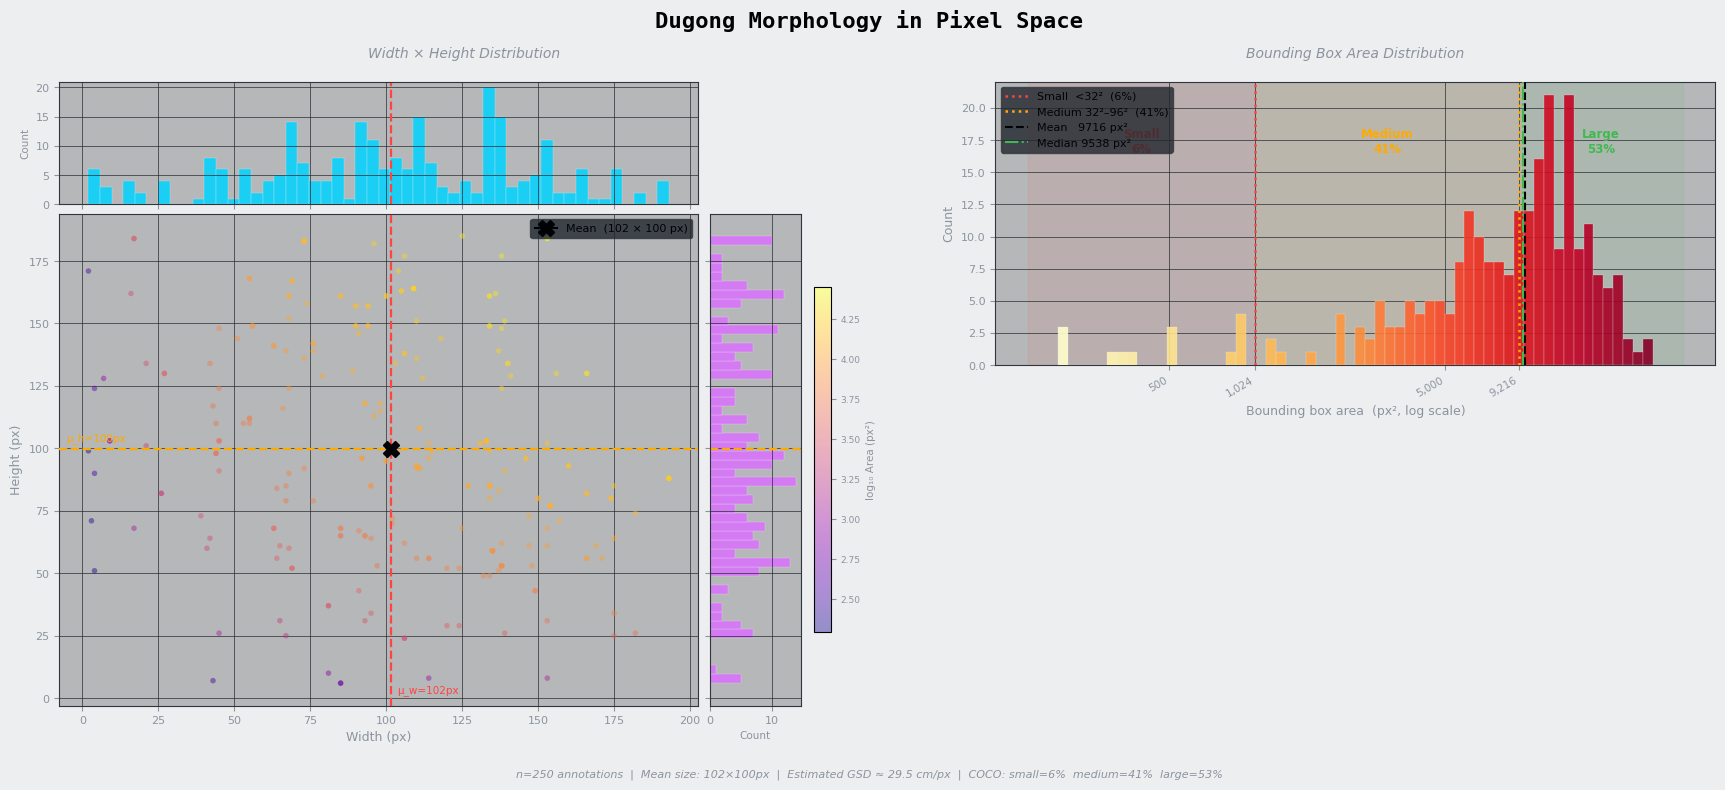

In [24]:
fig, widths, heights, areas = plot_dugong_morphology_dashboard(
    dataset
)

In [25]:
from fiftyone import ViewField as F

# Width and height in pixels using metadata dimensions
small_view = dataset.filter_labels(
    "ground_truth",
    (F("bounding_box")[2] * F("$metadata.width")  < 50) &
    (F("bounding_box")[3] * F("$metadata.height") < 50)
)

print(f"Images with small dugongs : {len(small_view)}")
print(f"Total small detections    : {small_view.count('ground_truth.detections')}")

Images with small dugongs : 2
Total small detections    : 2


In [27]:
session.view = small_view

In [ ]:
dataset